In [1]:
import pandas as pd
import duckdb
import os
import os, json
from uuid import uuid4
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#pd.set_option("display.width", 500)  # adjusts total line width before wrapping
import numpy as np
import pickle
from sentence_transformers import SentenceTransformer
import faiss
from sklearn.preprocessing import normalize
import gspread
from gspread_dataframe import get_as_dataframe, set_with_dataframe
from google.oauth2 import service_account # based on google-auth library
import matplotlib.pyplot as plt
import re
import unicodedata
from sklearn.preprocessing import normalize
import numpy as np
import json

In [2]:
try:
    file_data = json.load(open(os.path.expanduser("~/ServiceAccountsKey.json")))
    # (2) transform the content into crendentials object
    credentials = service_account.Credentials.from_service_account_info(file_data)
# (3) specify your usage of the credentials
    scoped_credentials = credentials.with_scopes(['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive'])
# (4) use the constrained credentials for authentication of gspread package
    gc = gspread.Client(auth=scoped_credentials)
    grela_gs = gc.open_by_url("https://docs.google.com/spreadsheets/d/1QroTEQ9gQf9cLO9mvolp7fELNbYYjgvGd48yAiTj03w/edit?usp=sharing")
except:
    pass

In [3]:
model = SentenceTransformer("julian-schelb/multilingual-e5-large-emb-lat-intertext-v1")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [64]:
vulgate_df = pd.read_parquet("../data/large_files/vulgate_df.parquet")

In [65]:
vulgate_df.columns

Index(['sentence_id', 'grela_id', 'sentence_position', 'sent_text', 'author',
       'title', 'tokens', 'chapter', 'verse', 'sent_text_clean'],
      dtype='str')

In [66]:
emb_matrix = np.load("../data/large_files/vulgate_embeddings.npz", allow_pickle=True)["embeddings"]

In [67]:
d = emb_matrix.shape[1]  # 768
index = faiss.IndexFlatIP(d)        # Inner product = cosine if normalized
index.add(emb_matrix)

In [68]:
query = "The Word became flesh and made his dwelling among us. We have seen his glory, the glory of the one and only Son, who came from the Father, full of grace and truth."
embedding = model.encode([query], convert_to_numpy=True)
# Normalize for cosine similarity
embedding = normalize(embedding, norm='l2')

In [69]:
k = 5  # number of nearest neighbors
scores, indices = index.search(embedding, k)

In [70]:
# scores, indices from: scores, indices = index.search(embedding, k)
top_idxs = indices[0].astype(int)         # shape (k,)
top_scores = scores[0].astype(float)      # shape (k,)

# Get the corresponding rows directly
matches_df = vulgate_df.iloc[top_idxs].copy().reset_index(drop=True)
matches_df["score"] = top_scores


In [71]:
matches_df

,sentence_id,grela_id,sentence_position,sent_text,author,title,tokens,chapter,verse,sent_text_clean,score
0,vulgate_tlg0031.tlg004.obi-lat_13,vulgate_tlg0031.tlg004.obi-lat,13,et Verbum caro factum est et habitavit in nobis et vidimus gloriam eius gloriam quasi unigeniti a Patre plenum gratiae et veritatis,Johnannine literature,John,"[{'chapter': '1', 'char_end': 2, 'char_start': 0, 'lemma': 'et', 'pos': 'CCONJ', 'token_id': 255344706, 'token_text': 'et', 'verse': '14'}, {'chapter': '1', 'char_end': 9, 'char_start': 3, 'lemma'...",1,14,et uerbum caro factum est et habitauit in nobis et uidimus gloriam eius gloriam quasi unigeniti a patre plenum gratiae et ueritatis,0.794845
1,vulgate_tlg0031.tlg005.obi-lat_247,vulgate_tlg0031.tlg005.obi-lat,247,cum autem esset plenus Spiritu Sancto intendens in caelum vidit gloriam Dei et Iesum stantem a dextris Dei et ait ecce video caelos apertos et Filium hominis a dextris stantem Dei,Luke (the evangelist),Acts,"[{'chapter': '7', 'char_end': 3, 'char_start': 0, 'lemma': 'cum', 'pos': 'ADP', 'token_id': 255005407, 'token_text': 'cum', 'verse': '55'}, {'chapter': '7', 'char_end': 9, 'char_start': 4, 'lemma'...",7,55,cum autem esset plenus spiritu sancto intendens in caelum uidit gloriam dei et iesum stantem a dextris dei et ait ecce uideo caelos apertos et filium hominis a dextris stantem dei,0.752596
2,vulgate_tlg0031.tlg010.obi-lat_78,vulgate_tlg0031.tlg010.obi-lat,78,donec occurramus omnes in unitatem fidei et agnitionis Filii Dei in virum perfectum in mensuram aetatis plenitudinis Christi,Pauline literature,Ephesians,"[{'chapter': '4', 'char_end': 5, 'char_start': 0, 'lemma': 'donec', 'pos': 'SCONJ', 'token_id': 255267117, 'token_text': 'donec', 'verse': '13'}, {'chapter': '4', 'char_end': 16, 'char_start': 6, ...",4,13,donec occurramus omnes in unitatem fidei et agnitionis filii dei in uirum perfectum in mensuram aetatis plenitudinis christi,0.752360
3,vulgate_tlg0031.tlg023.obi-lat_71,vulgate_tlg0031.tlg023.obi-lat,71,in hoc apparuit caritas Dei in nobis quoniam Filium suum unigenitum misit Deus in mundum ut vivamus per eum,Johnannine literature,1 John,"[{'chapter': '4', 'char_end': 2, 'char_start': 0, 'lemma': 'in', 'pos': 'ADP', 'token_id': 255033170, 'token_text': 'in', 'verse': '9'}, {'chapter': '4', 'char_end': 6, 'char_start': 3, 'lemma': '...",4,9,in hoc apparuit caritas dei in nobis quoniam filium suum unigenitum misit deus in mundum ut uiuamus per eum,0.749398
4,vulgate_tlg0031.tlg019.obi-lat_37,vulgate_tlg0031.tlg019.obi-lat,37,Christus vero tamquam filius in domo sua quae domus sumus nos si fiduciam et gloriam spei usque ad finem firmam retineamus,Novum Testamentum,Hebrews,"[{'chapter': '3', 'char_end': 8, 'char_start': 0, 'lemma': 'Christus', 'pos': 'PROPN', 'token_id': 254996658, 'token_text': 'Christus', 'verse': '6'}, {'chapter': '3', 'char_end': 13, 'char_start'...",3,6,christus uero tamquam filius in domo sua quae domus sumus nos si fiduciam et gloriam spei usque ad finem firmam retineamus,0.739645


In [72]:
register_df = pd.read_parquet("../data/large_files/register_df_with_embeddings.parquet")

In [73]:


def detect_vulgate_verse(embedding_json, min_sim=0.6):
    if isinstance(embedding_json, str):
        embedding = np.array(json.loads(embedding_json)).reshape(1, -1).astype('float32')
    else:
        embedding = np.array(embedding_json).reshape(1, -1).astype('float32')

    embedding = embedding / np.linalg.norm(embedding, axis=1, keepdims=True)
    scores, indices = index.search(embedding, 1)
    score = scores[0][0]
    idx = indices[0][0]

    if score >= min_sim:
        row = vulgate_df.iloc[idx]

        return score, row["sent_text_clean"], row["author"], row["title"], row["chapter"], row["verse"]  # score, sentence_id, text, title
    else:
        return None, None, None, None, None, None

In [74]:
def safe_detect(row):
    if len(row["sent_text_clean"].split()) > 5:
        return detect_vulgate_verse(row["embedding"])
    else:
        return (None, None, None, None, None, None)

register_df[["score", "vulgate_text_clean", "author", "title", "chapter", "verse"]] = (
    register_df.apply(safe_detect, axis=1, result_type="expand")
)

In [75]:
len(register_df)

5399

In [76]:
register_df["score"].notnull().sum()

np.int64(4506)

In [85]:
for n in range(60, 100, 5):
    min_score = n / 100
    print(min_score, sum(register_df["score"] >= min_score))

0.6 4506
0.65 4506
0.7 4413
0.75 1600
0.8 124
0.85 29
0.9 11
0.95 3


In [86]:
register_matches = register_df[register_df["score"] >= 0.75].copy()

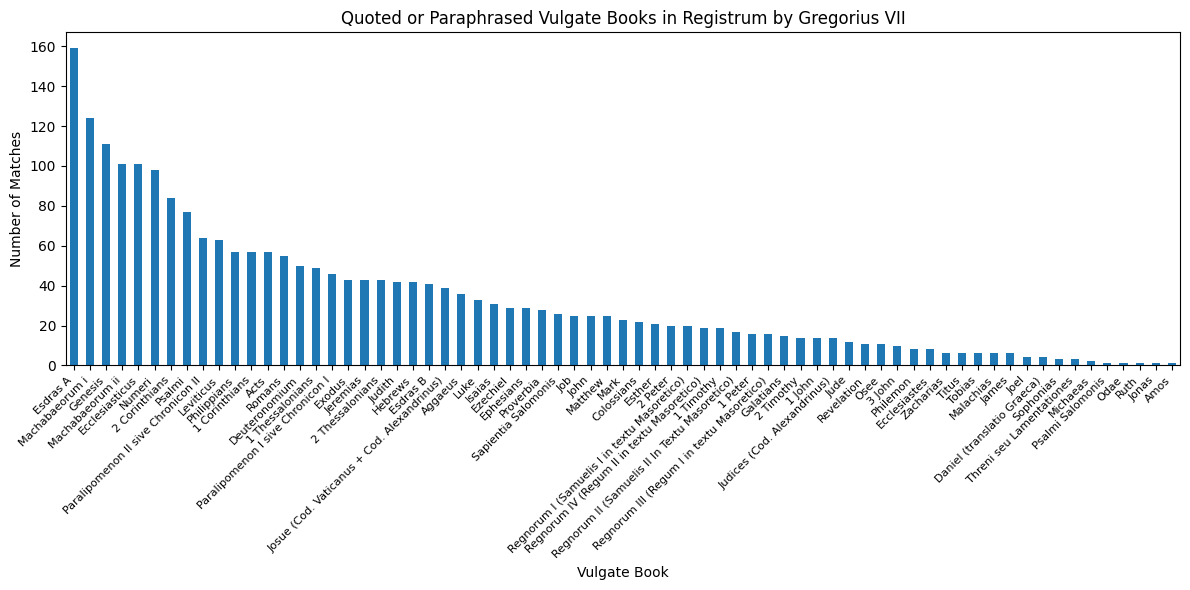

In [87]:
# Filter only matched rows (non-null vulgate_title)
# Count occurrences
title_counts = matched["title"].value_counts()

# Plot
plt.figure(figsize=(12, 6))
title_counts.plot(kind="bar")
plt.xlabel("Vulgate Book")
plt.ylabel("Number of Matches")
plt.title("Quoted or Paraphrased Vulgate Books in Registrum by Gregorius VII")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

In [88]:
register_matches.sort_values("score", ascending=False, inplace=True)

In [89]:
register_matches = register_matches[['sentence_id', 'register_ref',  'sent_text', 'sent_text_clean', 'vulgate_text_clean', 'author',
       'title', 'chapter', 'verse', 'score']]
register_matches.head(5)

,sentence_id,register_ref,sent_text,sent_text_clean,vulgate_text_clean,author,title,chapter,verse,score
2957,cc_10265_366,23;4,Quare faciem tuam avertis oblivisceris inopiae nostrae et tribulationis nostrae,quare faciem tuam auertis obliuisceris inopiae nostrae et tribulationis nostrae,quare faciem tuam auertis obliuisceris inopiae nostrae et tribulationis nostrae,NaN,Psalmi,43,24,1.000000
2572,cc_10265_3312,234;4,Et illud Tanquam prodigium factus sum multis et tu adjutor fortis,et illud tanquam prodigium factus sum multis et tu adiutor fortis,tamquam prodigium factus sum multis et tu adiutor fortis,NaN,Psalmi,70,7,0.972064
1240,cc_10265_2113,155;4,Posui te hodie super gentes et regna ut evellas et destruas et disperdas et dissipes et aedifices et plantes,posui te hodie super gentes et regna ut euellas et destruas et disperdas et dissipes et aedifices et plantes,ecce constitui te hodie super gentes et super regna ut euellas et destruas et disperdas et dissipes et aedifices et plantes,NaN,Jeremias,1,10,0.957367
1742,cc_10265_2566,184;4,Majorem charitatem nemo habet ut animam suam ponat quis pro amicis suis,maiorem charitatem nemo habet ut animam suam ponat quis pro amicis suis,maiorem hac dilectionem nemo habet ut animam suam quis ponat pro amicis suis,Johnannine literature,John,15,13,0.939601
2924,cc_10265_363,23;4,Non enim sunt condignae passiones hujus temporis ad superventuram gloriam quae revelabitur in nobis,non enim sunt condignae passiones huius temporis ad superuenturam gloriam quae reuelabitur in nobis,existimo enim quod non sunt condignae passiones huius temporis ad futuram gloriam quae reuelabitur in nobis,Paul of Tarsus,Romans,8,18,0.938122


In [91]:
register_matches.to_parquet("../data/register_matches_v4.parquet")

In [92]:
set_with_dataframe(grela_gs.add_worksheet("grela_register_matches_v4", 1,1), register_matches)

## Going deeper into subsentence